# TRUST Additional Validation Data

## First combine data from genotypic samples and patients

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle, re, collections, shutil
from functools import reduce

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq
from evcouplings.align import Alignment

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings
warnings.filterwarnings("ignore")

# load all utils functions
# sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
# from data_utils import *
# from inSilicoMut_utils import *

os.chdir("../")
sys.path.append("utils")
from data_utils import *
from inSilicoMut_utils import *

from matplotlib.ticker import FormatStrFormatter
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
model_loci = pd.read_csv("./data_processing/data_utils/drug_loci.csv")

# # who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
# who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_resistance_variants_all.csv")
# who_variants_clean = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")

# coll2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
# coll2014["#lineage"] = coll2014["#lineage"].str.replace("lineage", "")
# coll2014.rename(columns={"#lineage": "Lineage"}, inplace=True)

# solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name=None)

# if len(solo_results) == 1:
#     solo_results = solo_results[list(solo_results.keys())[0]]

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETA",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/WHO_catalog_isolate_variants.csv")

In [ ]:
# fastq_db_have = os.listdir("/n/data1/hms/dbmi/farhat/rollingDB/fastq_db")

In [85]:
# for fName in fNames_annot:
#     os.rename(fName, fName.replace('VCF', 'VCF_annot'))

In [3]:
# lineages_df = []

# for i, row in df.iterrows():

#     if pd.isnull(row['F2']):
#         F2_score = float(pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/240528.TRUST.Illumina.Batch4.Output/{row['ROLLINGDB_ID']}/lineage_calling/{row['ROLLINGDB_ID']}_F2_Coll2014.txt", sep='\t', header=None)[0].values[0])
        
#         lineages = pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/240528.TRUST.Illumina.Batch4.Output/{row['ROLLINGDB_ID']}/lineage_calling/{row['ROLLINGDB_ID']}_lineage.tsv", sep='\t')

#         lineages.columns = ['ROLLINGDB_ID', 'Coll2014', 'Freschi2020', 'Lipworth2019', 'Shitikov2017', 'Stucki2016']
#         lineages['F2'] = F2_score
#         lineages_df.append(lineages)

# lineages_df = pd.concat(lineages_df)
# lineages_df['ROLLINGDB_ID'] = [val.split("_")[0] for val in lineages_df['ROLLINGDB_ID']]
# lineages_df['Coll2014'] = lineages_df['Coll2014'].str.replace('lineage', '')

In [18]:
def combine_TRUST_patient_samples(df_trust_patients, samples_report):

    print(f"{len(df_trust_patients.patient_num.unique())} patients in TRUST/data_20240124.csv")
    
    # each sample ID is in the format like 260-04, S0299-01, or S0271-01A. So use re to remove all alpha characters and keep only numbers.
    # first number is the patient number, second is the sample number
    # merge the patient number extracted from each sample with the patient numbers in df_trust_patients
    samples_report["patient_num"] = [int(re.findall(r'\d+', val.split("-")[0])[0]) for val in samples_report["original ID"].values]
    samples_report["sample_week"] = [int(re.findall(r'\d+', val.split("-")[1])[0]) for val in samples_report["original ID"].values]

    # keep only samples for the patients in df_trust_patients
    #df_trust_report = df_trust_report.query("patient_num in @df_trust_patients.patient_num.unique()")
    samples_report = samples_report.merge(df_trust_patients[["pid", "patient_num"]], on="patient_num", how="inner")
    print(f"Found {len(samples_report.patient_num.unique())}/{len(df_trust_patients.patient_num.unique())} patients in TRUST/2023-01-24_report_Farhat.v09.xlsx")
    
    # rename some columns that have spaces in them
    samples_report = samples_report.rename(columns={"Cov Any Mean": "Cov_Any_Mean",
                                        "Cov Unam Perc": "Cov_Unam_Perc",
                                        "Perc. Reads Mapped": "Perc_Reads_Mapped",
                                        "original ID": "original_ID",
                                        "phylogenetic classification (Coll et al., 2014)": "Coll2014_Annotated"
                                       })

    samples_report["Coll2014"] = [val.split(" ")[0] for val in samples_report["Coll2014_Annotated"].values]
    samples_report["Lineage"] = [val.split(".")[0] for val in samples_report["Coll2014"].values]

    # get VCF file paths
    samples_report = samples_report.reset_index(drop=True)
    
    for i, row in samples_report.iterrows():

        sample_id = row["SampleID"]
        fName = f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF/{sample_id}.eff.vcf"

        if os.path.isfile(fName):
            samples_report.loc[i, "VCF"] = fName
        # failed kraken classification: meaning fewer than 90% of reads aligned to MTBC database
        # else:
        # # if not found_vcf_file:
        #     print(f"VCF file for {sample_id} not found!")

    # also remove contaminated samples
    print(samples_report.comment.value_counts())
    return samples_report

In [19]:
df_trust_patients = pd.read_csv("./analysis/TRUST_MIC_20240124.csv", index_col=[0])
df_trust_patients["patient_num"] = [int(patient_id.replace("T0", "")) for patient_id in df_trust_patients["pid"].values]

trust_report = pd.read_excel("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/2023-09-01_report_Farhat.v09.xlsx", sheet_name=None)
df_trust_report = trust_report["summary"].dropna(axis=0, how='all')
print(df_trust_report.shape)

# remove failed and contaminated samples
df_trust_report = df_trust_report.query("status != 'failed' & ~comment.str.contains('contaminated')").reset_index(drop=True)
print(df_trust_report.shape)

(445, 11)
(408, 11)


In [20]:
# df_trust = combine_TRUST_patient_samples(df_trust_patients, df_trust_report)

# # from Sarah Thompson email on 09/15/2023 
# exclude_lst = ['T0086', 'T0248', 'T0254', 'T0267', 'T0279']
# df_trust = df_trust.query("pid not in @exclude_lst")
# df_trust.to_csv("./analysis/TRUST_combined_samples_patients.csv", index=False)

df_trust = pd.read_csv("./analysis/TRUST_combined_samples_patients.csv")
print(f"{df_trust.pid.nunique()} pids have WGS passing quality control")
print(f"{df_trust.SampleID.nunique()} WGS samples")

234 pids have WGS passing quality control
395 WGS samples


# Create summary figure of the MICs of the 4 first-line drugs (these are the only MICs that were tested)

In [21]:
highQual_pheno_cols = []

for col in df_trust_patients.columns[df_trust_patients.columns.str.contains('mic_sputum_specimen')]:

    not_null = len(df_trust_patients.loc[~pd.isnull(df_trust_patients[col])])

    # PZA very low (70%), but that's all the data we have
    if not_null / len(df_trust_patients) > 0.25:
        print(col, not_null / len(df_trust_patients))
        highQual_pheno_cols.append(col)

TRUST_phenos = df_trust_patients[["pid"] + highQual_pheno_cols]

# keep only pids that have WGS available
TRUST_phenos = TRUST_phenos.query("pid in @df_trust.pid.values")
print(f"{len(TRUST_phenos)} patients have MICs and WGS data")

RIF_label_encoding_dict = {1: '≤0.03', 2: '0.03-0.06', 3: '0.06-0.125', 4: '0.125-0.25', 5: '0.25-0.5', 6: '0.5-1', 7: '>1'}
INH_label_encoding_dict = {1: '≤0.025', 2: '0.025-0.05', 3: '0.05-0.1', 4: '0.1-0.2', 5: '>0.2'}
EMB_label_encoding_dict = {1: '≤0.6', 2: '0.6-1.25', 3: '1.25-2.5', 4: '2.5-5', 5: '>5'}
PZA_label_encoding_dict = {1: '≤25', 2: '25-50', 3: '50-75', 4: '75-100', 5: '>100'}

s_inhmic_sputum_specimen_1 0.9696202531645569
s_rifmic_sputum_specimen_1 0.9696202531645569
s_embmic_sputum_specimen_1 0.9696202531645569
s_pzamic_sputum_specimen_1 0.6987341772151898
395 patients have MICs and WGS data


In [22]:
TRUST_plot_phenos = pd.DataFrame(TRUST_phenos.melt(id_vars="pid")[["variable", "value"]].query("variable.str.contains('sputum')").value_counts()).reset_index()

TRUST_plot_phenos.columns = ["Drug", "MIC_group", "Count"]

TRUST_plot_phenos["Drug"] = TRUST_plot_phenos["Drug"].replace("s_embmic_sputum_specimen_1", "Ethambutol"
                                                    ).replace("s_rifmic_sputum_specimen_1", "Rifampicin",
                                                    ).replace("s_inhmic_sputum_specimen_1", "Isoniazid",
                                                    ).replace("s_pzamic_sputum_specimen_1", "Pyrazinamide")

In [23]:
def create_stacked_percent_bar_chart(df, x_order, palettes, index_var="Drug", col_var="MIC_group", count_var="Count", saveName=None):
    
    # set the figure size
    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    df_stacked_for_plotting = df.pivot(index=index_var, columns=col_var, values=count_var).fillna(0).astype(int)
    df_stacked_for_plotting["Total"] = df_stacked_for_plotting.sum(axis=1)

    # compute proportions for plotting
    for group in df[col_var].unique():
        df_stacked_for_plotting[group] = df_stacked_for_plotting[group] / df_stacked_for_plotting["Total"]
        
    del df_stacked_for_plotting["Total"]
    df_stacked_for_plotting = df_stacked_for_plotting.reset_index().melt(id_vars=index_var)
        
    # keep track of all the groups to increase the start value of the next bar
    prev_vals_array = np.zeros(len(df_stacked_for_plotting[index_var].unique()))
    
    # order in increasing lineage abundance for each drug
    df_stacked_for_plotting = df_stacked_for_plotting.sort_values([index_var, "value"], ascending=[True, False])

    # add string labels to the dataframe. Use these to label the bar segments with
    for i, row in df_stacked_for_plotting.iterrows():
    
        if row["Drug"] == "Rifampicin":
            df_stacked_for_plotting.loc[i, "Label"] = RIF_label_encoding_dict[row[col_var]]
        elif row["Drug"] == "Isoniazid":
            df_stacked_for_plotting.loc[i, "Label"] = INH_label_encoding_dict[row[col_var]]
        elif row["Drug"] == "Ethambutol":
            df_stacked_for_plotting.loc[i, "Label"] = EMB_label_encoding_dict[row[col_var]]
        elif row["Drug"] == "Pyrazinamide":
            df_stacked_for_plotting.loc[i, "Label"] = PZA_label_encoding_dict[row[col_var]]
        else:
            raise ValueError(f"{row['Drug']} is not a valid drug name!")

    # reorder the dataframe to match the plotting order so that we can add bar labels properly
    # Convert the 'Category' column to Categorical data type with the desired order
    df_stacked_for_plotting[f'{col_var}_categorical'] = pd.Categorical(df_stacked_for_plotting[index_var], categories=x_order, ordered=True)
    df_stacked_for_plotting = df_stacked_for_plotting.sort_values([col_var, f'{col_var}_categorical']).reset_index(drop=True)
    
    # iterate through the Lineages and convert to percentages
    column_groups = df_stacked_for_plotting[col_var].unique()
    
    for i, column_group in enumerate(column_groups):  
                        
        # dataframe of proportion of each drug's samples that belong to the current lineage
        single_group = df_stacked_for_plotting[df_stacked_for_plotting[col_var]==column_group].groupby(index_var)["value"].sum().reset_index()
        single_group = single_group.set_index(index_var).loc[x_order, :].reset_index()
        
        if i > 0:
            prev_vals = df_stacked_for_plotting[df_stacked_for_plotting[col_var]==column_groups[i-1]].groupby(index_var)["value"].sum().reset_index()
            prev_vals = prev_vals.set_index(index_var).loc[x_order, :].reset_index()["value"].values 
            prev_vals_array += prev_vals
            
        ax.bar(single_group[index_var].values, 
               single_group["value"].values, 
               bottom = prev_vals_array, 
               edgecolor="black",
               label=column_group,
               width=0.5
              )       
    
    label_loc = 'center'
    sigfig = 2
    font_size = '7'

    # Get the patches from ax
    patches = ax.get_children()
    rect_patches = [patch for patch in patches if isinstance(patch, plt.Rectangle)]
    
    # variable to iterate over the product of len(col_var) * len(index_var). In this case, = 15
    count_idx = -1
    num_drugs = len(x_order)
    # len(ax.containers) = the number of unique values in col_var
    for cont in ax.containers:
        
        labels = []

        # len(cont) = the number of unique values in index_var
        for val in cont.datavalues:

            # iterate for every value
            count_idx += 1

            # update the patch color
            use_palette = palettes[count_idx % num_drugs]
            new_color = use_palette[count_idx // num_drugs]
            rect_patches[count_idx].set_facecolor(new_color)
            
            if val > 0.025:
                labels.append(df_stacked_for_plotting["Label"].values[count_idx])
            else:
                labels.append("")

        ax.bar_label(cont, labels=labels, label_type=label_loc, fontsize=font_size)

    # fig.canvas.draw()

    text = ax.text(
        x=1,  # x-coordinate of the text
        y=1.012,  # y-coordinate of the text
        s='>0.2',  # text content
        fontsize=7,  # font size of the text
        color='black',  # color of the text
        ha='center',  # horizontal alignment of the text (optional)
        va='center'  # vertical alignment of the text (optional)
    )

    # text = ax.text(
    #     x=3,  # x-coordinate of the text
    #     y=1.012,  # y-coordinate of the text
    #     s='75-100',  # text content
    #     fontsize=7,  # font size of the text
    #     color='black',  # color of the text
    #     ha='center',  # horizontal alignment of the text (optional)
    #     va='center'  # vertical alignment of the text (optional)
    # )

    plt.xticks(fontsize="8")
    plt.yticks(fontsize="7")
    plt.ylabel("Proportion", fontsize="8")
    plt.setp(ax.patches, linewidth=0.75)
    plt.ylim(0, 1.025)
    sns.despine()
    
    if saveName is not None:
        plt.savefig(saveName, dpi=300, bbox_inches='tight')
    else:
        plt.show()

    return df_stacked_for_plotting.reset_index(drop=True)

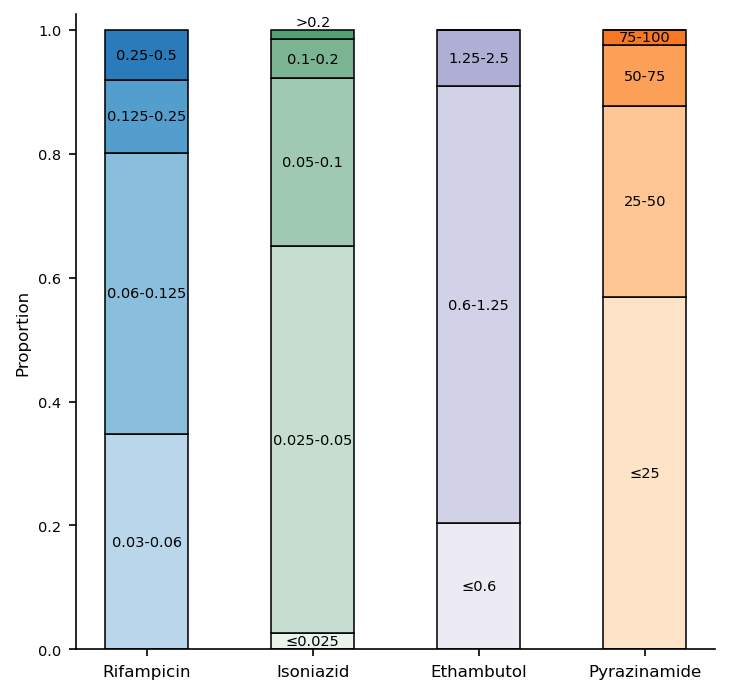

In [24]:
index_var = "Drug"
col_var = "MIC_group"
count_var = "Count"
x_order = ["Rifampicin", "Isoniazid", "Ethambutol", "Pyrazinamide"]

df_stacked_for_plotting = create_stacked_percent_bar_chart(TRUST_plot_phenos, 
                                                           x_order, 
                                                           palettes=[sns.color_palette("Blues").as_hex(),
                                                                     sns.light_palette("seagreen").as_hex(),
                                                                     sns.color_palette("Purples").as_hex(),
                                                                     sns.color_palette("Oranges").as_hex(),
                                                                    ],
                                                           index_var="Drug", 
                                                           col_var="MIC_group", 
                                                           count_var="Count",
                                                           saveName="results/TRUST_phenos_barchart.png"
                                                          )

In [25]:
TRUST_plot_phenos.groupby('Drug')['Count'].sum()

Drug
Ethambutol      383
Isoniazid       383
Pyrazinamide    276
Rifampicin      383
Name: Count, dtype: int64

In [26]:
def get_TRUST_predicted_and_actual_MICs(drug, model_path, MIC_encoding_dict):

    mic_col = f"s_{drug.lower()}mic_sputum_specimen_1"
    MIC_encoding_dict_rev = {val: key for key, val in MIC_encoding_dict.items()}

    df_TRUST_predict = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{model_path}/TRUST/test_predictions.csv")

    # keep only patients with measured MICs, remove samples with a high F2 score, and then keep the earliest WGS sample if there are multiple per pid
    df_TRUST_predict = df_TRUST_predict[['ROLLINGDB_ID', 'log2_pred_MIC', 'pred_MIC']].merge(df_trust_patients, left_on='ROLLINGDB_ID', right_index=True).dropna(subset=f"s_{drug.lower()}mic_sputum_specimen_1").query("F2 <= 0.05").sort_values("sample_week", ascending=True)
    
    # convert the MIC categorical variable to a lower bound and upper bound
    bounds_df = pd.DataFrame(df_TRUST_predict[mic_col].map(MIC_encoding_dict).str.split(",", expand=True))
    bounds_df.columns = [f"{drug}_lower_bound", f"{drug}_upper_bound"]
    bounds_df = pd.concat([df_TRUST_predict[["pid"]], bounds_df], axis=1)
    
    bounds_df[[f"{drug}_lower_bound", f"{drug}_upper_bound"]] = bounds_df[[f"{drug}_lower_bound", f"{drug}_upper_bound"]].astype(float)
    bounds_df[f"{drug}_midpoint"] = (bounds_df[f"{drug}_lower_bound"] + bounds_df[f"{drug}_upper_bound"]) / 2
    
    return bounds_df.merge(df_TRUST_predict, on="pid", how="inner").drop_duplicates()

In [27]:
def compare_predicted_actual_MIC(drug, model_path, MIC_encoding_dict, label_encoding_dict, palette="Blues", model="CNN", saveName=None):

    if model not in ["CNN", "Reg"]:
        raise ValueError(f"{model} must be 'CNN' or 'Reg'")
        
    df_patient_data = get_TRUST_predicted_and_actual_MICs(drug, model_path, MIC_encoding_dict)

    # compute binned mae. Don't need mse and within_doubling
    mae, _, _ = boundedLoss_predict(df_patient_data, y_pred_col="log2_pred_MIC", lower_bounds_col=f"{drug}_lower_bound", upper_bounds_col=f"{drug}_upper_bound")

    mic_col = "pred_MIC"
    plot_col = "pred_MIC_group"
    
    for group, bounds_str in MIC_encoding_dict.items():
    
        lower_bound, upper_bound = np.array(bounds_str.split(",")).astype(float)
        df_patient_data.loc[(df_patient_data[mic_col] > lower_bound) & (df_patient_data[mic_col] <= upper_bound), plot_col] = group

    var1_categories = df_patient_data[f"s_{drug.lower()}mic_sputum_specimen_1"].unique()
    var2_categories = df_patient_data[plot_col].unique()
    categories = list(set(var1_categories).union(var2_categories))

    overlap = pd.crosstab(df_patient_data[f"s_{drug.lower()}mic_sputum_specimen_1"], df_patient_data[plot_col])

    # reverse the y-ticks (index) because by default they are increasing DOWN, but we want them to increase UP
    overlap = overlap.reindex(index=categories[::-1], columns=categories, fill_value=0)
    
    # Create the heatmap
    fig, ax = plt.subplots()
    sns.heatmap(overlap, annot=True, cmap=palette, linewidths=0.25, linecolor="black", ax=ax, clip_on=False, fmt='g')
    
    old_labels = [float(val.get_text()) for val in ax.get_xticklabels()]
    new_labels = pd.Series(old_labels).map(label_encoding_dict)
    
    ax.set_xticks(ticks=ax.get_xticks(), labels=new_labels, fontsize="8")

    # reverse the y-ticks because by default they are increasing DOWN, but we want them to increase UP
    ax.set_yticks(ticks=ax.get_yticks(), labels=new_labels[::-1], rotation=0, fontsize="8")
    
    plt.xlabel("\nPredicted MIC (µg/mL)", fontsize="10")
    plt.ylabel("Actual MIC (µg/mL)", fontsize="10")
    
    sns.despine()

    predicted_correct = df_patient_data.query(f"s_{drug.lower()}mic_sputum_specimen_1 == {plot_col}").shape[0]
    predicted_EA = df_patient_data.query(f"~((s_{drug.lower()}mic_sputum_specimen_1 - {plot_col} > 1) | ({plot_col} - s_{drug.lower()}mic_sputum_specimen_1 > 1))").shape[0]

    plt.title(f"Categorical Accuracy: {np.round(predicted_correct / len(df_patient_data) * 100, 1)}%\nEsssential Agreement: {np.round(predicted_EA / len(df_patient_data) * 100, 1)}%\nMean Absolute Error: {np.round(mae, 2)} log2-MIC")

    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName, dpi=300, bbox_inches="tight")

    print(f"{len(df_patient_data)} samples")
    return df_patient_data

In [28]:
def compute_predicted_MIC_diff(drug, model_path):

    df_TRUST_predict = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{model_path}/TRUST/test_predictions.csv")

    # keep only patients with measured MICs, remove samples with a high F2 score, and then keep the earliest WGS sample if there are multiple per pid
    df_TRUST_predict = df_TRUST_predict[['ROLLINGDB_ID', 'pred_MIC']].merge(df_trust_patients, left_on='ROLLINGDB_ID', right_index=True).dropna(subset=f"s_{drug.lower()}mic_sputum_specimen_1").query("F2 <= 0.05").sort_values("sample_week", ascending=True)
    
    # when there are multiple isolates per pid, each one has a predicted MIC
    # get the largest difference between the predictions
    predicted_MICs_per_pid = df_TRUST_predict.groupby('pid')['pred_MIC'].agg(['min', 'max'])
    predicted_MICs_per_pid['diff'] = predicted_MICs_per_pid['max'] - predicted_MICs_per_pid['min']
    
    print(f"{len(predicted_MICs_per_pid.query('diff != 0'))} pids have multiple predicted MICs")
    print(f"Maximum difference in predictions: {np.round(predicted_MICs_per_pid.query('diff != 0')['diff'].max(), 4)} µg/mL")

    return df_TRUST_predict.sort_values(['pid', 'ROLLINGDB_ID'])

# Rifampicin

3 pids have multiple predicted MICs
Maximum difference in predictions: 0.0175 µg/mL


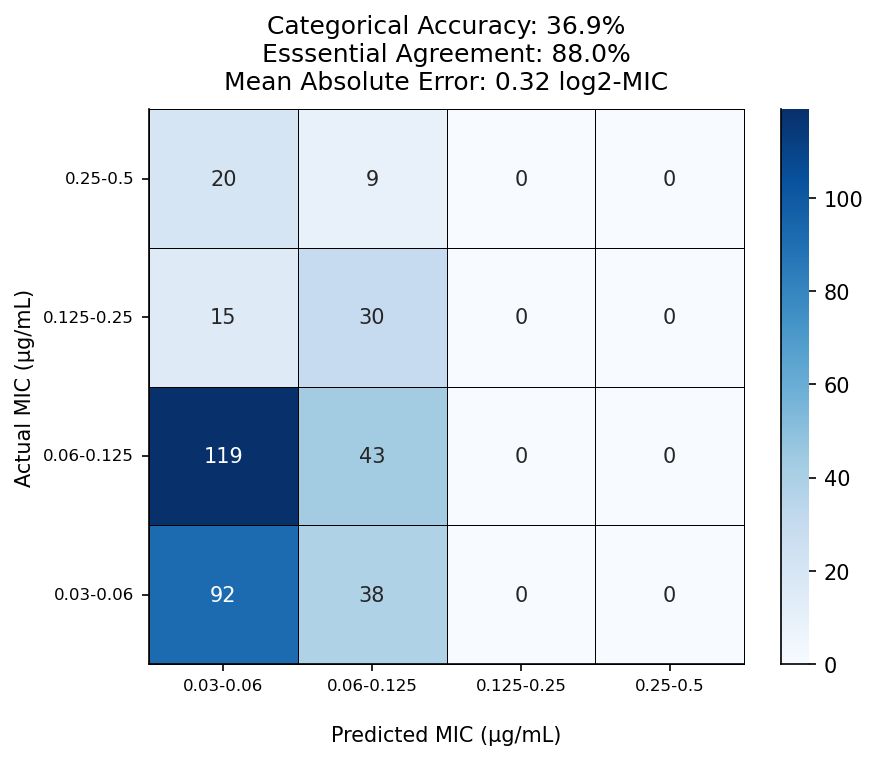

366 samples


In [64]:
RIF_MIC_encoding_dict = {1: '0,0.03', 2: '0.03,0.06', 3: '0.06,0.125', 4: '0.125,0.25', 5: '0.25,0.5', 6:'0.5,10000'}
RIF_label_encoding_dict = {1: '≤0.03', 2: '0.03-0.06', 3: '0.06-0.125', 4: '0.125-0.25', 5: '0.25-0.5', 6: '>0.5'}

drug = "RIF"
model_path = "RIF_lineage_amino_acid"

diff_MICs_by_pid = compute_predicted_MIC_diff(drug, model_path)

RIF_pred = compare_predicted_actual_MIC(drug, model_path, RIF_MIC_encoding_dict, RIF_label_encoding_dict, palette=sns.color_palette("Blues", as_cmap=True), model="CNN")

In [65]:
isolates_with_RIF_R_variants = isolate_variants.query("ROLLINGDB_ID in @RIF_pred.ROLLINGDB_ID & drug=='Rifampicin' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").ROLLINGDB_ID.unique()

len(isolates_with_RIF_R_variants)

0

In [73]:
isolate_variants.query("ROLLINGDB_ID in @RIF_pred.ROLLINGDB_ID & drug=='Rifampicin' & EFFECT != 'synonymous_variant' & GENE in ['rpoB', 'rpoC']")[['variant', 'confidence']].value_counts()

variant           confidence               
rpoC_p.Gly594Glu  5) Not assoc w R             49
rpoC_p.Thr225Asn  3) Uncertain significance     5
rpoB_p.Glu738Ala  3) Uncertain significance     1
rpoC_p.Asp271Gly  5) Not assoc w R              1
Name: count, dtype: int64

# Isoniazid

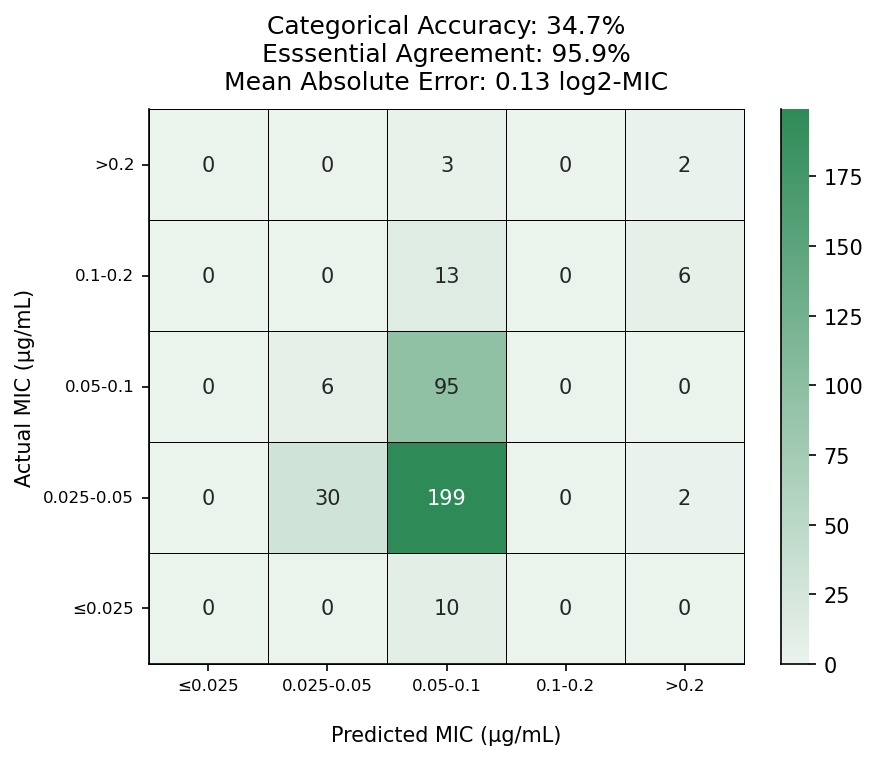

366 samples


In [30]:
# WITH LINEAGE
INH_MIC_encoding_dict = {1: '0,0.025', 2: '0.025,0.05', 3: '0.05,0.1', 4: '0.1,0.2', 5: '0.2,100000'}
INH_label_encoding_dict = {1: '≤0.025', 2: '0.025-0.05', 3: '0.05-0.1', 4: '0.1-0.2', 5: '>0.2'}

drug = "INH"
model_path = "INH_lineage_amino_acid"

INH_pred = compare_predicted_actual_MIC(drug, model_path, INH_MIC_encoding_dict, INH_label_encoding_dict, palette=sns.light_palette("seagreen", as_cmap=True), model="CNN", )#saveName="Isoniazid/validation/TRUST_CNN_predictions_heatmap.png")

In [31]:
INH_pred.query("s_inhmic_sputum_specimen_1==5").sort_values("pred_MIC", ascending=False)

,pid,INH_lower_bound,INH_upper_bound,INH_midpoint,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,original_ID,shipment,status,...,s_inhmic_sputum_specimen_1,s_rifmic_sputum_specimen_1,s_embmic_sputum_specimen_1,s_pzamic_sputum_specimen_1,VCF,F2,log2_pred_MIC_exp,within_doubling,compute_error,pred_MIC_group
638,T0322,0.2,100000.0,50000.1,MFS-387,1.612971,3.058811,S0322-05,3rd,in progress,...,5.0,3.0,2.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.019911,3.06,1,0,5.0
128,T0007,0.2,100000.0,50000.1,MFS-3,-1.127062,0.457847,07-01,1st,finished,...,5.0,3.0,2.0,NaN,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.008367,0.46,1,0,5.0
65,T0331,0.2,100000.0,50000.1,MFS-397,-3.975218,0.063583,S0331-01,3rd,in progress,...,5.0,3.0,2.0,4.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.009786,0.06,0,1,3.0
570,T0030,0.2,100000.0,50000.1,MFS-15,-4.304075,0.050623,30-01,1st,finished,...,5.0,2.0,1.0,NaN,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.014397,0.05,0,1,3.0
66,T0331,0.2,100000.0,50000.1,MFS-398,-4.313548,0.050291,S0331-07,3rd,in progress,...,5.0,3.0,2.0,4.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010220,0.05,0,1,3.0


In [36]:
INH_pred.query("pred_MIC_group==5 & s_inhmic_sputum_specimen_1 < 4").columns

Index(['pid', 'INH_lower_bound', 'INH_upper_bound', 'INH_midpoint',
       'ROLLINGDB_ID', 'log2_pred_MIC', 'pred_MIC', 'original_ID', 'shipment',
       'status', 'comment', 'SampleLib', 'Coll2014_Annotated', 'quality',
       'Cov_Any_Mean', 'Cov_Unam_Perc', 'Perc_Reads_Mapped', 'patient_num',
       'sample_week', 'Coll2014', 'Lineage', 's_inhmic_sputum_specimen_1',
       's_rifmic_sputum_specimen_1', 's_embmic_sputum_specimen_1',
       's_pzamic_sputum_specimen_1', 'VCF', 'F2', 'log2_pred_MIC_exp',
       'within_doubling', 'compute_error', 'pred_MIC_group'],
      dtype='object')

In [36]:
# CNN predicted R, but low MIC
# not due to lineage because L2.2.1 SNP prediction is same as H37Rv
# both have inhA_c.-777C>T
INH_pred.query("pred_MIC_group==5 & s_inhmic_sputum_specimen_1 < 4")[['pid', 'ROLLINGDB_ID', 'Coll2014_Annotated', 'quality',
       'Cov_Any_Mean', 'Cov_Unam_Perc', 'Perc_Reads_Mapped', 'patient_num',
       'sample_week', 'Coll2014', 'Lineage', 's_inhmic_sputum_specimen_1',
       's_rifmic_sputum_specimen_1', 's_embmic_sputum_specimen_1',
       's_pzamic_sputum_specimen_1', 'VCF', 'F2', 'log2_pred_MIC_exp',
       'within_doubling', 'compute_error', 'pred_MIC_group']]

,pid,ROLLINGDB_ID,Coll2014_Annotated,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,patient_num,sample_week,Coll2014,...,s_inhmic_sputum_specimen_1,s_rifmic_sputum_specimen_1,s_embmic_sputum_specimen_1,s_pzamic_sputum_specimen_1,VCF,F2,log2_pred_MIC_exp,within_doubling,compute_error,pred_MIC_group
5,T0108,MFS-360,2.2.1 Beijing,1.0,282.80,0.99,0.9913,108,1,2.2.1,...,2.0,2.0,3.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010495,0.46,0,1,5.0
6,T0108,MFS-361,2.2.1 Beijing,1.0,316.37,0.99,0.9901,108,8,2.2.1,...,2.0,2.0,3.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.012076,0.46,0,1,5.0


In [52]:
# INH-R, but CNN underpredicts
# not due to lineage because L2.2.1 SNP prediction is same as H37Rv
INH_pred.query("pred_MIC_group < 4 & s_inhmic_sputum_specimen_1 == 5")[['pid', 'ROLLINGDB_ID', 'Coll2014_Annotated', 'quality',
       'Cov_Any_Mean', 'Cov_Unam_Perc', 'Perc_Reads_Mapped', 'patient_num',
       'sample_week', 'Coll2014', 'Lineage', 's_inhmic_sputum_specimen_1',
       's_rifmic_sputum_specimen_1', 's_embmic_sputum_specimen_1',
       's_pzamic_sputum_specimen_1', 'VCF', 'F2', 'log2_pred_MIC_exp',
       'within_doubling', 'compute_error', 'pred_MIC_group']]

,pid,ROLLINGDB_ID,Coll2014_Annotated,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,patient_num,sample_week,Coll2014,...,s_inhmic_sputum_specimen_1,s_rifmic_sputum_specimen_1,s_embmic_sputum_specimen_1,s_pzamic_sputum_specimen_1,VCF,F2,log2_pred_MIC_exp,within_doubling,compute_error,pred_MIC_group
65,T0331,MFS-397,2.2.1 Beijing Asian/Africa 2,1.0,185.66,0.99,0.9380,331,1,2.2.1,...,5.0,3.0,2.0,4.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.009786,0.06,0,1,3.0
66,T0331,MFS-398,2.2.1 Beijing Asian/Africa 2,1.0,249.98,0.99,0.9862,331,7,2.2.1,...,5.0,3.0,2.0,4.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010220,0.05,0,1,3.0
570,T0030,MFS-15,3 Delhi-CAS,1.0,314.53,1.00,0.9899,30,1,3,...,5.0,2.0,1.0,NaN,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.014397,0.05,0,1,3.0


In [56]:
isolate_variants.query("ROLLINGDB_ID in ['MFS-397', 'MFS-398', 'MFS-15'] & drug=='Isoniazid'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
15370,MFS-484,575907,C,T,PASS,8947.0,False,1.00,271.0,33.0,60.0,0.0,0.0,missense_variant,mshA,c.560C>T,p.Ala187Val,mshA_p.Ala187Val,Isoniazid,5) Not assoc w R
15388,MFS-484,1406760,T,TG,PASS,8557.0,False,0.99,258.0,34.0,60.0,256.0,0.0,frameshift_variant,Rv1258c,c.580_581insC,p.Glu194fs,Rv1258c_p.Glu194fs,Isoniazid,5) Not assoc w R
15393,MFS-484,1673425,C,T,PASS,8470.0,False,1.00,260.0,33.0,60.0,0.0,0.0,intergenic_region,Rv1482c-fabG1,n.1673425C>T,NaN,inhA_c.-777C>T,Isoniazid,1) Assoc w R
15397,MFS-484,2154724,C,A,PASS,9094.0,False,1.00,281.0,33.0,60.0,0.0,0.0,missense_variant,katG,c.1388G>T,p.Arg463Leu,katG_p.Arg463Leu,Isoniazid,5) Not assoc w R


In [49]:
isolates_with_INH_R_variants = isolate_variants.query("ROLLINGDB_ID in @INH_pred.ROLLINGDB_ID & drug=='Isoniazid' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").ROLLINGDB_ID.unique()

len(isolates_with_INH_R_variants)

8

In [55]:
INH_pred.query("ROLLINGDB_ID in @isolates_with_INH_R_variants").sort_values("pred_MIC")

,pid,INH_lower_bound,INH_upper_bound,INH_midpoint,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,original_ID,shipment,status,...,s_inhmic_sputum_specimen_1,s_rifmic_sputum_specimen_1,s_embmic_sputum_specimen_1,s_pzamic_sputum_specimen_1,VCF,F2,log2_pred_MIC_exp,within_doubling,compute_error,pred_MIC_group
571,T0239,0.100,0.20,0.1500,MFS-148,-1.707145,0.306266,239-01,1st,finished,...,4.0,2.0,2.0,NaN,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.016809,0.31,1,1,5.0
572,T0239,0.100,0.20,0.1500,MFS-149,-1.707145,0.306266,239-06,1st,finished,...,4.0,2.0,2.0,NaN,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.017557,0.31,1,1,5.0
650,T0305,0.100,0.20,0.1500,MFS-314,-1.226722,0.427287,S0305-08,2nd,finished,...,4.0,3.0,2.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.011380,0.43,0,1,5.0
5,T0108,0.025,0.05,0.0375,MFS-360,-1.127062,0.457847,S0108-01,3rd,finished,...,2.0,2.0,3.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010495,0.46,0,1,5.0
6,T0108,0.025,0.05,0.0375,MFS-361,-1.127062,0.457847,S0108-08,3rd,finished,...,2.0,2.0,3.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.012076,0.46,0,1,5.0
128,T0007,0.200,100000.00,50000.1000,MFS-3,-1.127062,0.457847,07-01,1st,finished,...,5.0,3.0,2.0,NaN,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.008367,0.46,1,0,5.0
375,T0392,0.100,0.20,0.1500,MFS-484,-1.127062,0.457847,S0392-01,3rd,finished,...,4.0,2.0,2.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010279,0.46,0,1,5.0
638,T0322,0.200,100000.00,50000.1000,MFS-387,1.612971,3.058811,S0322-05,3rd,in progress,...,5.0,3.0,2.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.019911,3.06,1,0,5.0


# Ethambutol

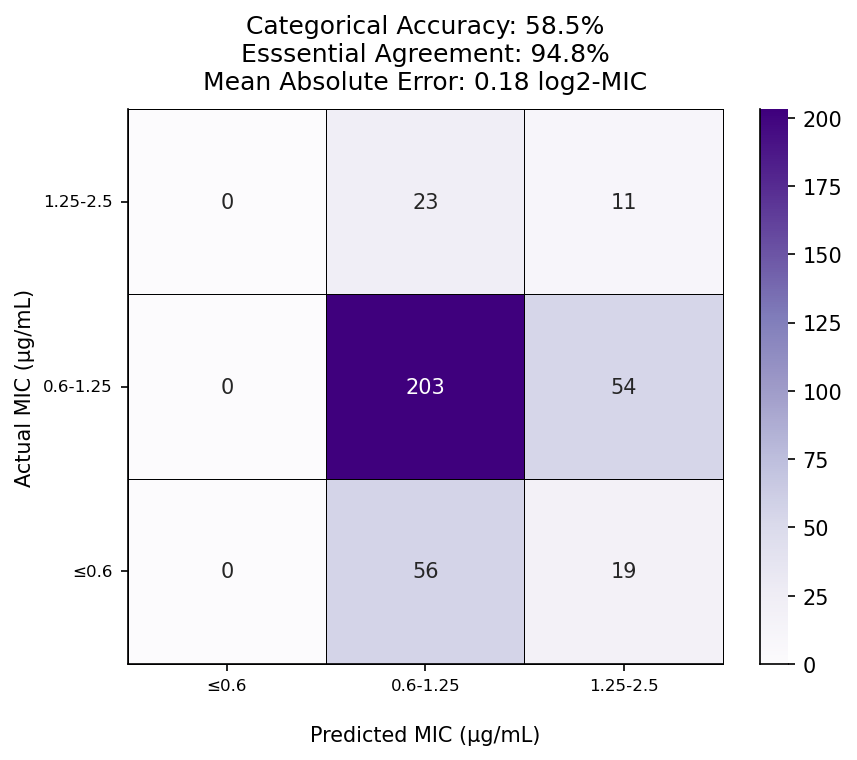

366 samples


In [59]:
EMB_MIC_encoding_dict = {1: '0,0.6', 2: '0.6,1.25', 3: '1.25,2.5', 4: '2.5,5', 5: '5,100000'}
EMB_label_encoding_dict = {1: '≤0.6', 2: '0.6-1.25', 3: '1.25-2.5', 4: '2.5-5', 5: '>5'}

drug = "EMB"
model_path = "EMB_lineage_amino_acid"

EMB_pred = compare_predicted_actual_MIC(drug, model_path, EMB_MIC_encoding_dict, EMB_label_encoding_dict, palette=sns.color_palette("Purples", as_cmap=True), model="CNN", )#saveName="Ethambutol/validation/TRUST_CNN_predictions_heatmap.png")

In [60]:
isolates_with_EMB_R_variants = isolate_variants.query("ROLLINGDB_ID in @EMB_pred.ROLLINGDB_ID & drug=='Ethambutol' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").ROLLINGDB_ID.unique()

len(isolates_with_EMB_R_variants)

0

# Pyrazinamide

3 pids have multiple predicted MICs
Maximum difference in predictions: 6.3324 µg/mL


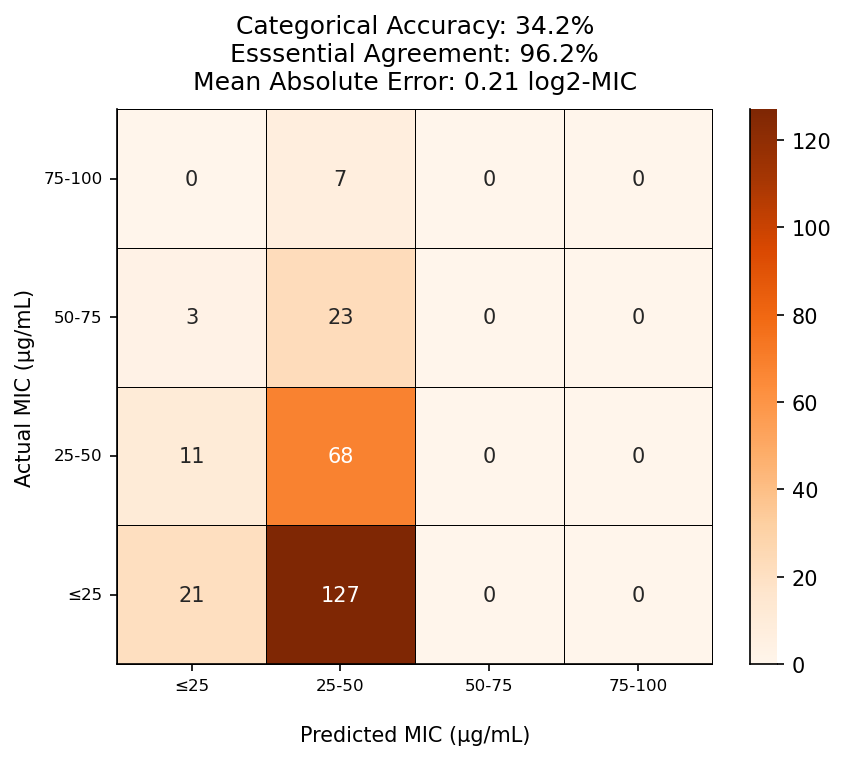

260 samples


In [61]:
PZA_MIC_encoding_dict = {1: '0,25', 2: '25,50', 3: '50,75', 4: '75,100', 5: '100,100000'}
PZA_label_encoding_dict = {1: '≤25', 2: '25-50', 3: '50-75', 4: '75-100', 5: '>100'}

drug = "PZA"
model_path = "PZA_amino_acid"
_ = compute_predicted_MIC_diff(drug, model_path)

PZA_pred = compare_predicted_actual_MIC(drug, model_path, PZA_MIC_encoding_dict, PZA_label_encoding_dict, palette=sns.color_palette("Oranges", as_cmap=True), model="CNN", )#saveName="results/Pyrazinamide/TRUST_amino_acid_predictions_heatmap.png")

3 pids have multiple predicted MICs
Maximum difference in predictions: 9.7502 µg/mL


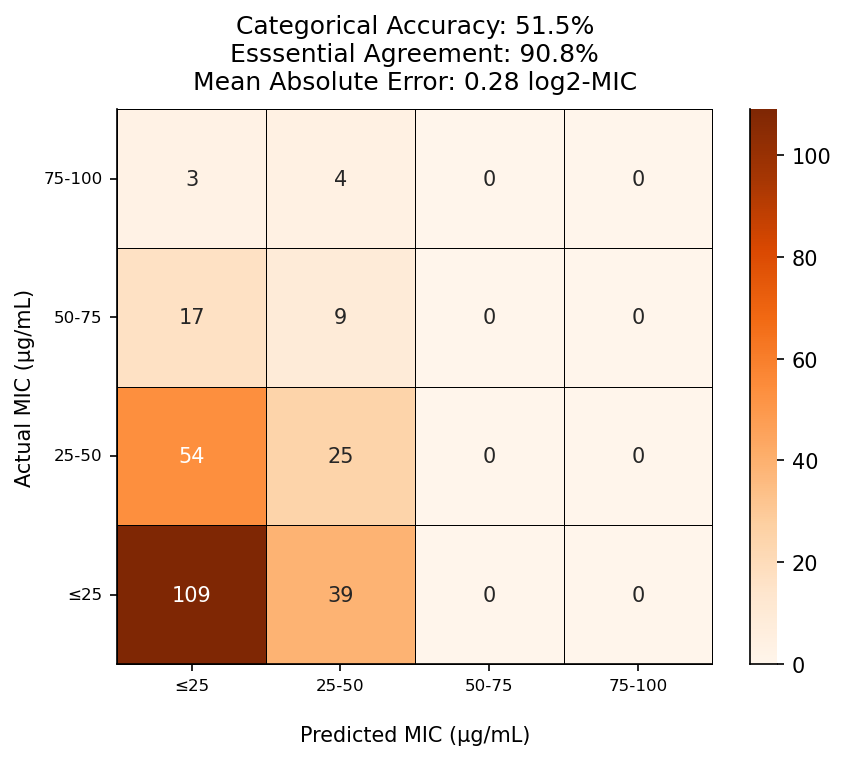

260 samples


In [62]:
PZA_MIC_encoding_dict = {1: '0,25', 2: '25,50', 3: '50,75', 4: '75,100', 5: '100,100000'}
PZA_label_encoding_dict = {1: '≤25', 2: '25-50', 3: '50-75', 4: '75-100', 5: '>100'}

drug = "PZA"
model_path = "PZA_lineage_amino_acid"
_ = compute_predicted_MIC_diff(drug, model_path)

PZA_pred = compare_predicted_actual_MIC(drug, model_path, PZA_MIC_encoding_dict, PZA_label_encoding_dict, palette=sns.color_palette("Oranges", as_cmap=True), model="CNN", )#saveName="results/Pyrazinamide/TRUST_amino_acid_predictions_heatmap.png")

In [63]:
isolates_with_PZA_R_variants = isolate_variants.query("ROLLINGDB_ID in @PZA_pred.ROLLINGDB_ID & drug=='Pyrazinamide' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").ROLLINGDB_ID.unique()

len(isolates_with_PZA_R_variants)

0

# Distribution of MICs per Unique Sequence

In [260]:
def plot_barplot_mics_per_seq(drug, drug_full_name, mic_label_encoding_dict, saveFig=False):

    drug_col = f"s_{drug.lower()}mic_sputum_specimen_1"
    fasta_files = glob.glob(os.path.join(data_dir, drug, "fastas", "TRUST", "*.fasta"))
    combined_seq_df = []
    
    for fName in fasta_files:
        fasta_seq = [(seq.id.split(".")[0], str(seq.seq)) for seq in SeqIO.parse(fName, "fasta")]
        seq_df = pd.DataFrame(fasta_seq)
        seq_df.columns = ["ROLLINGDB_ID", os.path.basename(fName).split(".")[0]]
        combined_seq_df.append(seq_df)
    
    combined_seq_df = reduce(lambda x, y: pd.merge(x, y, on = 'ROLLINGDB_ID'), combined_seq_df).set_index('ROLLINGDB_ID')
    
    # string concatenate (join) all loci
    combined_seq_df = pd.DataFrame(combined_seq_df.apply(''.join, axis=1))
    combined_seq_df.columns = ['Seq']
    combined_seq_df = combined_seq_df.reset_index()
    
    combined_seq_df = combined_seq_df.merge(df_trust[['ROLLINGDB_ID', 'pid']].merge(df_trust_patients[['pid', drug_col]].dropna(axis=0), on='pid'), left_on='ROLLINGDB_ID', right_on='SampleID')
    del combined_seq_df['ROLLINGDB_ID']
    
    seq_num_mapping = dict(zip(combined_seq_df.Seq.unique(), np.arange(len(combined_seq_df.Seq.unique())).astype(str)))
    combined_seq_df["Seq_Num"] = combined_seq_df["Seq"].map(seq_num_mapping)
    
    _, seq_counts = np.unique(combined_seq_df["Seq_Num"], return_counts=True)

    # minimum number of isolates with a given sequence -- should be at least 2, otherwise there is just a single isolate with an MIC. that would just be clutter
    isolate_thresh = 2
    
    # keep only unique sequences with at least 2 isolates
    # plot_df = combined_seq_df.groupby('Seq_Num').filter(lambda x: len(x) >= isolate_thresh)
    
    # keep only unique sequences with at least 2 different measured MICs
    plot_df = combined_seq_df.groupby('Seq_Num').filter(lambda x: x[drug_col].nunique() >= isolate_thresh)
    
    seq_num_order = plot_df.groupby("Seq_Num")[drug_col].mean().sort_values(ascending=True).index.values
    
    plot_df_matrix = pd.DataFrame(plot_df.groupby('Seq_Num')[drug_col].value_counts()).reset_index().pivot(index="Seq_Num", columns=drug_col, values="count").fillna(0).astype(int)
    plot_df_matrix = plot_df_matrix.loc[seq_num_order]
    
    totals_by_seq_group = plot_df_matrix.sum(axis=1).values

    if drug == 'RIF':
        colors = sns.color_palette("Blues", n_colors=len(plot_df_matrix.columns))
    elif drug == 'PZA':
        colors = sns.color_palette("Oranges", n_colors=len(plot_df_matrix.columns))
    elif drug == 'INH':
        sns.light_palette("seagreen", n_colors=len(plot_df_matrix.columns))
    elif drug == 'EMB':
        colors = sns.light_palette("Purples", n_colors=len(plot_df_matrix.columns))
    
    plot_df_matrix_percents = plot_df_matrix.copy()
    
    # convert to percentages
    for col in plot_df_matrix_percents.columns:
        plot_df_matrix_percents[col] = plot_df_matrix_percents[col] / totals_by_seq_group * 100
        
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    # keep track of all the groups to increase the start value of the next bar
    prev_vals_array = np.zeros(len(plot_df_matrix_percents))
    
    for i, mic_group in enumerate(plot_df_matrix_percents.columns):        
                                
        ax.bar(seq_num_order, 
               plot_df_matrix_percents[mic_group], 
               color=colors[i], 
               bottom = prev_vals_array, 
               edgecolor="black",
               linewidth=0.7,
               label=mic_group,
               alpha=0.75,
              )
    
    
        # plot the bar sizes (percentages) and the true counts
        for k, seq_group in enumerate(plot_df_matrix_percents.index.values):
    
            val = plot_df_matrix_percents.loc[seq_group, mic_group]
                
            # bottom of the current box    
            y_lower = plot_df_matrix_percents.loc[seq_group, plot_df_matrix_percents.columns[:i + 1]].values.sum()

            # top of the current box
            y_upper = plot_df_matrix_percents.loc[seq_group, plot_df_matrix_percents.columns[:i]].values.sum()

            y_pos = np.mean([y_lower, y_upper])
    
            if val > 0:
                combined_label = f"{int(np.round(val))}%\n(N={plot_df_matrix.loc[seq_group, mic_group]})"
                
                # small numbers for which the bars are too short to accommodate the whole number, put on top
                if val < 3:
                    ax.text(seq_group, y_pos + 1, combined_label, ha='center', va='bottom', fontsize='8')
                else:
                    ax.text(seq_group, y_pos, combined_label, ha='center', va='center', fontsize='8')
    
        # increment bottom
        prev_vals_array += plot_df_matrix_percents[mic_group]
        
        # adjust legend manually to show the exact MIC ranges with the colors, NOT the integer groups
    
    handles, labels = ax.get_legend_handles_labels()    
    
    # RIF_label_encoding_dict keys are integers, but labels are strings
    mic_labels = [mic_label_encoding_dict[int(float(val))] for val in labels]
    
    # Set the legend handles
    ax.legend(handles, mic_labels)
    plt.xticks([], [])
    ax.margins(x=0.01)
    sns.despine()
    
    sns.move_legend(ax, fontsize=10, title='MIC Range (µg/mL)', loc='upper right', #bbox_to_anchor=(1.05, 0.65),
                    ncol=len(colors),
                   bbox_to_anchor=(0.75, -0.02))
    
    plt.title(f"{drug_full_name} MICs for {len(plot_df)} Isolates across {len(seq_num_order)} Unique Concatenated {len(fasta_files)}-Loci Sequences\n")

    if saveFig:
        plt.savefig(f"TRUST/{drug}_barplot_MICS_by_seq.png", dpi=300, bbox_inches='tight')
    else:
        plt.show()

    return plot_df_matrix

In [261]:
_ = plot_barplot_mics_per_seq("RIF", "Rifampicin", RIF_label_encoding_dict, saveFig=True)

TypeError: reduce() of empty sequence with no initial value

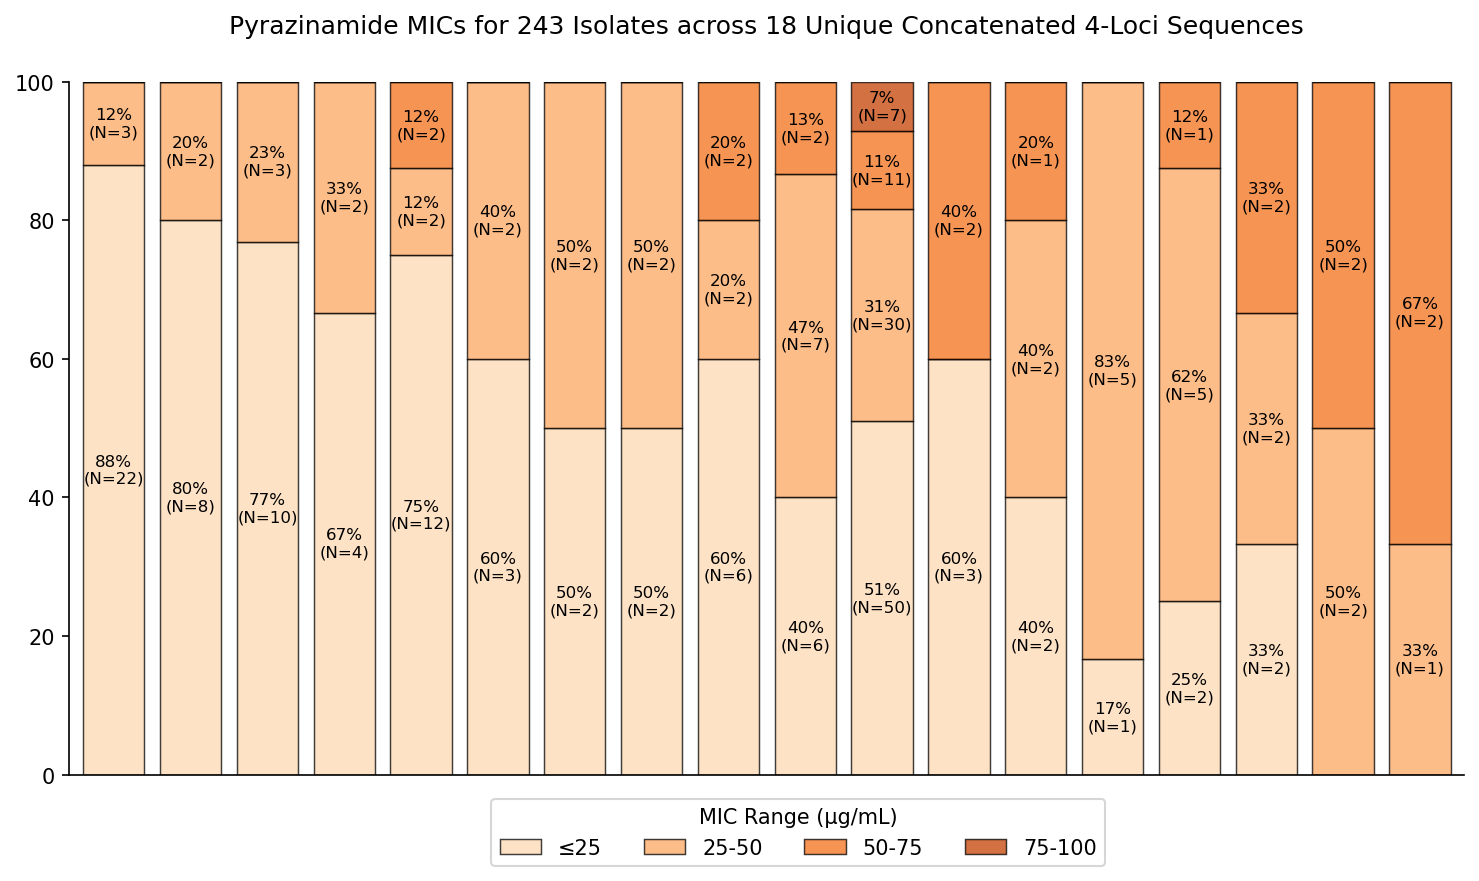

In [117]:
_ = plot_barplot_mics_per_seq("PZA", "Pyrazinamide", PZA_label_encoding_dict, saveFig=True)

# Variants in Isolates

In [126]:
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/isolate_variants.csv.gz", compression='gzip')

In [127]:
RIF_isolate_variants = isolate_variants.query("Isolate in @RIF_patient_data.SampleID & ((POS > 759309 & POS <= 767683) | (POS > 3877432 & POS <= 3878507))").reset_index(drop=True)
PZA_isolate_variants = isolate_variants.query("Isolate in @PZA_patient_data.SampleID & ((POS > 2286526 & POS <= 2291268) | (POS > 4038050 & POS <= 4040980) | (POS > 1833379 & POS <= 1836386) | (POS > 4042940 & POS <= 4046302))").reset_index(drop=True)

len(RIF_isolate_variants), len(PZA_isolate_variants)

(477, 1124)

In [128]:
def get_syn_variant_counts_by_sample(isolate_variants_df, patient_data_df, drug):

    for i, row in isolate_variants_df.iterrows():
    
        if pd.isnull(row['PROT']):
            isolate_variants_df.loc[i, 'MUT'] = row['GENE'] + '_' + row['NUC']
        else:
            if row['PROT'].replace('p.', '')[:3] == row['PROT'][-3:]:
                isolate_variants_df.loc[i, 'MUT'] = row['GENE'] + '_' + row['NUC']
                isolate_variants_df.loc[i, 'PROT'] = np.nan
            else:
                isolate_variants_df.loc[i, 'MUT'] = row['GENE'] + '_' + row['PROT']

    syn_variants = isolate_variants_df.loc[(pd.isnull(isolate_variants_df['PROT'])) & (~isolate_variants_df['GENE'].str.contains('-'))].reset_index(drop=True)

    # merge with the full list of sample IDs so that isolates without any variants are included here and have a variant count of 0
    syn_variants = syn_variants.merge(patient_data_df[['SampleID']], left_on='Isolate', right_on='SampleID', how='right')
    
    # get the number of synonymous variants per sample. Includes all samples because we merged right above
    syn_variants_by_sample = pd.DataFrame(syn_variants.groupby('SampleID')['MUT'].count()).reset_index()
    
    # add in actual and predicted MICs
    syn_variants_by_sample = syn_variants_by_sample.merge(patient_data_df[['SampleID', f's_{drug.lower()}mic_sputum_specimen_1', 'pred_MIC_group']])

    return isolate_variants_df, syn_variants_by_sample

In [133]:
RIF_isolate_variants, RIF_syn_variants_by_sample = get_syn_variant_counts_by_sample(RIF_isolate_variants, RIF_patient_data, 'RIF')
PZA_isolate_variants, PZA_syn_variants_by_sample = get_syn_variant_counts_by_sample(PZA_isolate_variants, PZA_patient_data, 'PZA')

In [138]:
pd.DataFrame(PZA_isolate_variants.loc[(~pd.isnull(PZA_isolate_variants['PROT'])) & (PZA_isolate_variants['GENE'].isin(['pncA', 'clpC1', 'rpsA', 'panD']))].MUT.value_counts())

,count
MUT,
rpsA_p.Met432Thr,12
pncA_p.Thr114Met,11
rpsA_p.Leu53Val,4
clpC1_p.Asp326Asn,1


In [142]:
pd.DataFrame(PZA_isolate_variants.loc[(pd.isnull(PZA_isolate_variants['PROT'])) & (PZA_isolate_variants['GENE'].isin(['pncA', 'clpC1', 'rpsA', 'panD']))].MUT.value_counts())

,count
MUT,
rpsA_c.636A>C,159
clpC1_c.2418C>T,47
pncA_c.195C>T,10
clpC1_c.1737G>A,7


In [143]:
pd.DataFrame(RIF_isolate_variants.loc[(pd.isnull(RIF_isolate_variants['PROT'])) & (~RIF_isolate_variants['GENE'].str.contains('-'))].MUT.value_counts())

,count
MUT,
rpoB_c.3225T>C,139
rpoC_c.1626C>G,39
rpoC_c.2701C>T,15
rpoB_c.2628T>G,9
rpoB_c.309C>T,6
rpoB_c.390C>T,3
rpoC_c.186C>T,3
rpoA_c.1026C>T,2
rpoC_c.1929G>A,1


In [124]:
for num_syn_var in np.sort(RIF_syn_variants_by_sample.MUT.unique()):

    actual_mic_group = RIF_syn_variants_by_sample.query("MUT==@num_syn_var")['s_rifmic_sputum_specimen_1'].mean()
    #pred_mic_group = RIF_syn_variants_by_samples.query("MUT==@num_syn_var")['pred_MIC_group'].mean() # these are identical because only one group was predicted for all isolates
    print(num_syn_var, actual_mic_group)

0 3.24
1 2.9226519337016574
2 2.6842105263157894
3 2.0


<Axes: xlabel='MUT', ylabel='s_rifmic_sputum_specimen_1'>

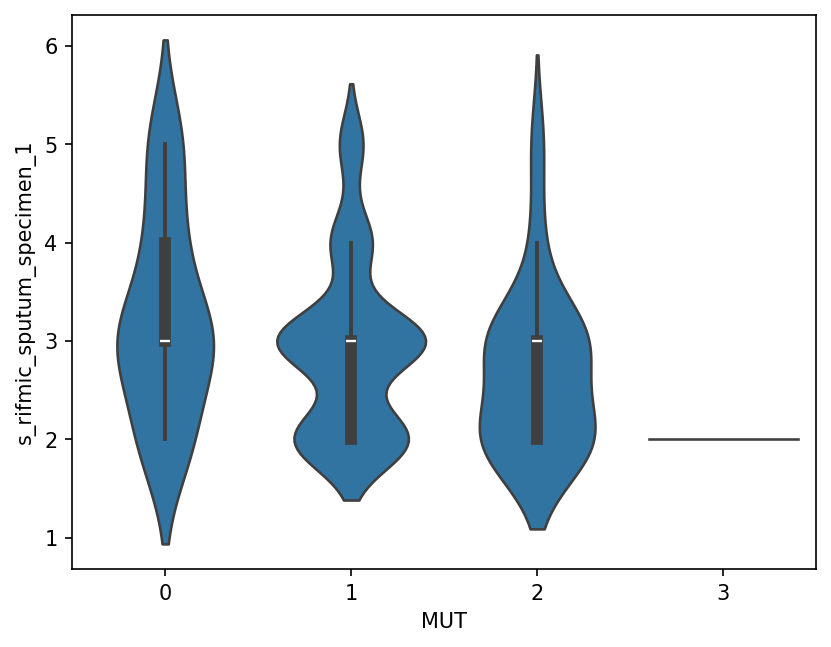

In [125]:
sns.violinplot(data=RIF_syn_variants_by_sample,
              x='MUT',
              y='s_rifmic_sputum_specimen_1'
             )